In [ ]:
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import os
from itertools import product
from typing import List, Tuple
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score, confusion_matrix, roc_curve, auc
from torch.amp import GradScaler, autocast  # Set device for GPU usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}, Device Name: {torch.cuda.get_device_name() if torch.cuda.is_available() else 'None'}")
print(torch.__version__)  # E.g., 2.4.0+cu118
print(torch.cuda.is_available())  # Should print True
from torch.utils.data import random_split
from torch.backends import cudnn
import torch.multiprocessing as mp
mp.set_start_method('spawn', force=True)  
from traindataset import SignatureVerificationDataset, genuine_extract_path, forgery_extract_path, transform
import torch._dynamo  
torch._dynamo.config.suppress_errors = True
torch._dynamo.config.verbose = False              # ← ADD THIS LINE
import time
import random
import logging
logging.getLogger("torch._dynamo").setLevel(logging.ERROR)


In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


In [4]:
torch.backends.cudnn.benchmark = True          # Huge speedup on fixed input size (256×256)
torch.backends.cuda.matmul.allow_tf32 = True   # +15–20% speed on Ampere/Ada (4060)
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')     # Use TensorFloat-32 where possible
os.environ["CUDA_LAUNCH_BLOCKING"] = "0"   

# DATA

In [41]:
dataset = SignatureVerificationDataset(
    genuine_dir=genuine_extract_path,
    forgery_dir=forgery_extract_path,
    transform=transform
)

dataloader = DataLoader(
    dataset, 
    batch_size=128,           # or 192/256 now that you use 64×64 images
    shuffle=True,
    num_workers=8,            # ← magic number for almost all gaming laptops
    pin_memory=True,          # ← very important with GPU
    prefetch_factor=2,
    persistent_workers=True
                       )


Genuine authors: 65, dict_keys(['001', '002', '003', '004', '006', '009', '012', '014', '015', '016', '021', '022', '023', '024', '025', '026', '027', '028', '029', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '100', '101', '102', '103', '104', '105'])
Forgery authors: 65, dict_keys(['014', '004', '015', '016', '002', '006', '012', '009', '001', '003', '021', '022', '023', '024', '025', '026', '027', '028', '029', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '100', '101', '102', '103', '104', '105'])
Author 001: 24 genuine s

In [6]:
from testdataset import SignatureVerificationTestDataset, reference_extract_path, ques_extract_path

testdataset = SignatureVerificationTestDataset(
    reference_extract_path,
    ques_extract_path,
    transform=transform
)
test_size = int(0.6 * len(testdataset))
val_size = len(testdataset) - test_size

test_dataset, val_dataset = random_split(testdataset,[test_size,val_size])

val_loader = DataLoader(val_dataset,
                        batch_size=128,           # or 192/256 now that you use 64×64 images
                        shuffle=False,
                        num_workers=6,            # ← magic number for almost all gaming laptops
                        pin_memory=True,          # ← very important with GPU
                        prefetch_factor=2,
                        persistent_workers=True
                       )

testdataloader = DataLoader(
    test_dataset,
    batch_size=128,           # or 192/256 now that you use 64×64 images
    shuffle=False,
    num_workers=6,            # ← magic number for almost all gaming laptops
    pin_memory=True,          # ← very important with GPU
    prefetch_factor=2,
    persistent_workers=True
)

20
Training Total pairs: 1287, Total labels: 1287
Training Positive pairs (label=1): 648
Training Negative pairs (label=0): 639
Genuine authors: 54, dict_keys(['013', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050', '051', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '062', '063', '064', '065', '066', '067', '068', '069'])
Forgery authors: 54, dict_keys(['013', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050', '051', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '062', '063', '064', '065', '066', '067', '068', '069'])
Author 013: 12 genuine signatures
Author 017: 12 g

In [42]:
class SiameseCNN(nn.Module):
    def __init__(self):
        super(SiameseCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 5, padding=2),    nn.BatchNorm2d(64),   nn.PReLU(),
            # nn.MaxPool2d(2),

            # nn.Conv2d(64, 128, 5, padding=2),  nn.BatchNorm2d(128),  nn.PReLU(),
            # nn.MaxPool2d(2),

            # nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256),  nn.PReLU(),
            # # nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256),  nn.PReLU(),
            # # nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256),  nn.PReLU(),
            # nn.MaxPool2d(2),

            nn.AdaptiveMaxPool2d((4, 4))   # → (B, 256, 1, 1)
        )

        # === Classifier head (after GAP) ===
        self.classifier = nn.Sequential(
            nn.Linear(64*4*4, 128),
            nn.PReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64)
        )

    def forward_one(self, x):
        x = self.features(x)           # → (B, 256, 1, 1)
        x = torch.flatten(x, 1)        # → (B, 256)   ← THIS WAS MISSING!
        x = self.classifier(x)         # → (B, 512)
        x = F.normalize(x, p=2, dim=1)  # ← L2 NORM — ABSOLUTELY CRITICAL!
        return x

    def forward(self, x1):
        emb1 = self.forward_one(x1)
        return emb1


In [43]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=0.3):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, emb1, emb2, label):
        cos_sim = torch.clamp(F.cosine_similarity(emb1, emb2),min=-1,max=1)
        pos = label*torch.pow(1-cos_sim,2)
        neg = (1-label)*torch.pow(F.relu(cos_sim-self.margin),2)
        return (pos + neg).mean()



In [44]:
plt.close('all')  # Close all open figuresos.makedirs('saved_models', exist_ok=True)
margin=-0.5
lr=0.00001
threshold=0.7
model=SiameseCNN()
model = torch.compile(model, mode="reduce-overhead")   # or "default"
model = model.to(device)

In [45]:
import torch.optim.lr_scheduler as lr_scheduler
criterion = ContrastiveLoss(margin=margin)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)  # AdamW > Adam
scaler = GradScaler()
# After optimizer definition
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # 'min' for minimizing loss; use 'max' if monitoring accuracy
    factor=0.1,       # Multiply lr by this (e.g., 0.0001 → 0.00001)
    patience=3,
    threshold=0,   # Wait this many epochs without improvement
    min_lr=1e-6       # Optional: Minimum lr to stop reducing below
)

In [ ]:
# Training with mixed precision
best_val_loss = float('inf')
early_stop_counter = 0
patience = 5
min_delta = 0.0005
num_epochs = 100
best_model_path = f"second_saved_models/savedmodels/dropoutCNN/best_siamese_margin{margin}_size64_lr{lr}.pt"

for epoch in range(num_epochs):
    # ─── Training ────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    start_time = time.time()

    for img1, img2, labels in dataloader:
        img1, img2, labels = (img1.to(device, non_blocking=True),
                              img2.to(device, non_blocking=True),
                              labels.to(device, non_blocking=True))
        optimizer.zero_grad(set_to_none=True)
        with autocast('cuda', dtype=torch.bfloat16):
            emb1 = model(img1)
            emb2 = model(img2)
            loss = criterion(emb1, emb2, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        num_batches += 1

    epoch_time = time.time() - start_time
    avg_train_loss = epoch_loss / num_batches
    scheduler.step(avg_train_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch:2d}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Time: {epoch_time:.1f}s | "
          f"LR: {current_lr:.6f}")
    

    # ─── Validation every 2 epochs ───────────────────────────────────
    if (epoch + 1) % 4 == 0:
        model.eval()
        val_losses = []
        cosine_sim_all = []
        labels_all = []

        with torch.no_grad():
            for img1_array, img2, labels in val_loader:
                # img1_array = list of 11 tensors, each (B, C, H, W)
                # stack → (N, B, C, H, W) = (11, 128, 1, 64, 64)
                img1_batch = torch.stack(img1_array).to(device, non_blocking=True)
                N, B, C, H, W = img1_batch.shape
            
                # Flatten to (N*B, C, H, W) for model
                img1_flat = img1_batch.reshape(N * B, C, H, W)
            
                with autocast("cuda", dtype=torch.bfloat16):
                    emb1_flat = model(img1_flat)                    # (N*B, emb_dim)
            
                # Reshape back to (N, B, emb_dim), then average across N references
                emb1 = emb1_flat.reshape(N, B, -1).mean(dim=0)    # (B, emb_dim)
            
                img2 = img2.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
            
                with autocast("cuda", dtype=torch.bfloat16):
                    emb2 = model(img2)                             # (B, emb_dim)
            
                distance = 1 - F.cosine_similarity(emb1, emb2)    # (B,)
                cosine_sim_all.append(distance)
                labels_all.append(labels)
            
                val_batch_loss = criterion(emb1, emb2, labels)
                val_losses.append(val_batch_loss.item())

        # Aggregate
        cosine_sim_all = torch.cat(cosine_sim_all)
        labels_all = torch.cat(labels_all)
        avg_val_loss = sum(val_losses) / len(val_losses)

        # Threshold tuning
        y_true = labels_all.cpu().numpy()
        fpr, tpr, thresholds_roc = roc_curve(y_true, 1 - cosine_sim_all.cpu().numpy())
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds_roc[optimal_idx]
        threshold = optimal_threshold
        y_pred = (cosine_sim_all.cpu().numpy() < threshold).astype(int)

        print(f"   Val Loss: {avg_val_loss:.6f} | "
              f"Acc: {accuracy_score(y_true, y_pred):.4f} | "
              f"Threshold: {threshold:.3f} | "
              f"Genuine: {cosine_sim_all[labels_all==1].mean():.3f} | "
              f"Forged: {cosine_sim_all[labels_all==0].mean():.3f}")

        # ─── Early Stopping ──────────────────────────────────────────
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"   → New best val loss: {best_val_loss:.6f} (saved)")
        else:
            early_stop_counter += 1
            print(f"   → No improvement. Patience: {early_stop_counter}/{patience}")

        if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch}. Best val loss: {best_val_loss:.6f}")
            break

        # Cleanup
        del cosine_sim_all, labels_all, y_true, y_pred
        torch.cuda.empty_cache()

# ─── Load best model ─────────────────────────────────────────────────
print("Loading best model for final evaluation...")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

Accuracy:  0.7097
Precision: 0.6589
Recall:    0.8257
F1-score:  0.7329
AUC:       0.7927


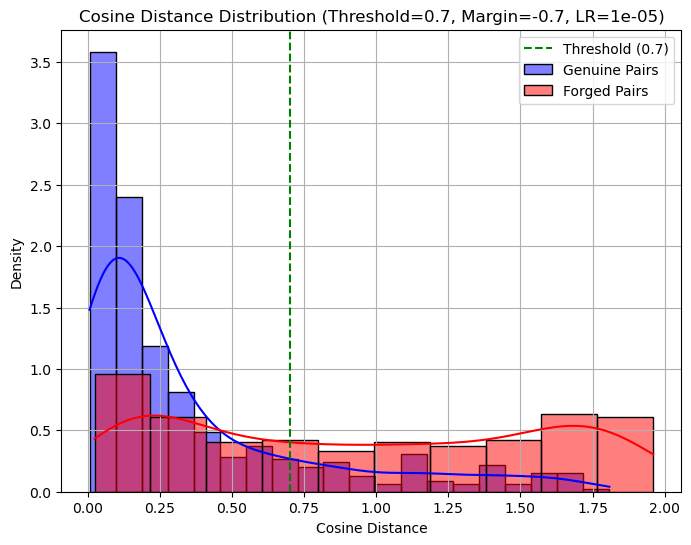

In [32]:
model_path = f"second_saved_models/savedmodels/dropoutCNN/siamese_margin{margin}_size64_dropout4_lr{lr}.pt"
model.load_state_dict(torch.load(model_path, map_location=device))
# torch.cuda.empty_cache()  # Clears GPU cache in PyTorch
model.eval()
correct = 0
total = 0
cosine_sim_all = []
labels_all = []
emb1_array=[]
with torch.no_grad():
    for img1_array, img2, labels in dataloader:
        img1=img1_array
        img1 = img1.to(device, non_blocking=True)
        with autocast("cuda", dtype=torch.bfloat16):
            emb1 = model(img1)
        img2 = img2.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with autocast("cuda", dtype=torch.bfloat16):
            emb2 = model(img2)
            
        cosine_sim = F.cosine_similarity(emb1, emb2)
        cosine_sim= (1-cosine_sim)
        cosine_sim_all.append(cosine_sim)
        labels_all.append(labels)
        total += labels.size(0)

    
    cosine_sim_all = torch.cat(cosine_sim_all)
    labels_all = torch.cat(labels_all)
    y_true = labels_all.cpu().numpy()
    y_pred = (cosine_sim_all.cpu().numpy() < threshold).astype(int)
    
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print(f"AUC:       {roc_auc_score(y_true, 1-cosine_sim_all.cpu().numpy()):.4f}")
    
    # Histogram
    indices = np.random.permutation(total)[:1000]
    cosine_sim_np = cosine_sim_all[indices].cpu().numpy()
    labels_np = labels_all[indices].cpu().numpy()
    cosine_sim_genuine = cosine_sim_np[labels_np == 1].tolist()
    cosine_sim_forged = cosine_sim_np[labels_np == 0].tolist()
    
    plt.figure(figsize=(8, 6))
    sns.histplot(cosine_sim_genuine, color='blue', label='Genuine Pairs', kde=True, stat='density')
    sns.histplot(cosine_sim_forged, color='red', label='Forged Pairs', kde=True, stat='density')
    plt.axvline(x=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
    plt.xlabel('Cosine Distance')
    plt.ylabel('Density')
    plt.title(f'Cosine Distance Distribution (Threshold={threshold}, Margin={margin}, LR={lr})')
    plt.legend()
    plt.grid(True)
    # plt.savefig(f"second_saved_models/saved_models/LENET/cosine_sim/cosine_similarity_distribution_threshold_{threshold}_{margin}_{lr}.png")
    plt.show()  # Display the plot
    plt.close()


Validation Accuracy (optimal threshold=0.414): 0.6136
Accuracy:  0.6408
Precision: 0.6561
Recall:    0.6288
F1-score:  0.6422
AUC:       0.6813


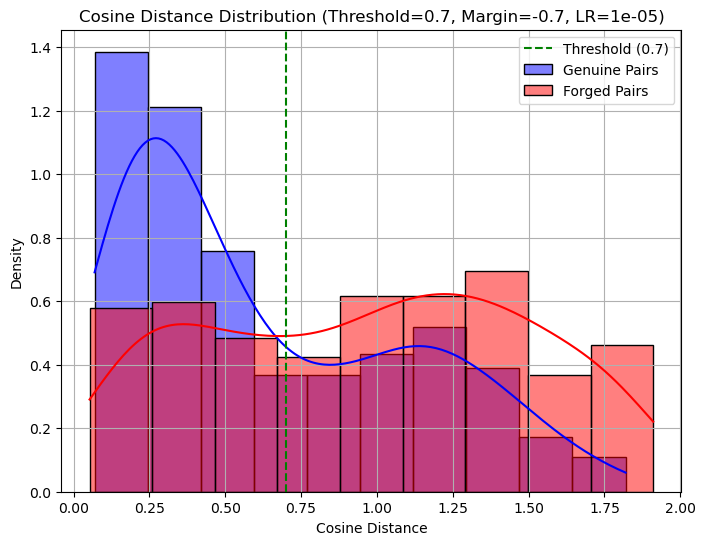

In [33]:
model_path = f"second_saved_models/savedmodels/dropoutCNN/siamese_margin{margin}_size64_dropout4_lr{lr}.pt"
model.load_state_dict(torch.load(model_path, map_location=device))
# torch.cuda.empty_cache()  # Clears GPU cache in PyTorch
model.eval()
correct = 0
total = 0
cosine_sim_all = []
labels_all = []
with torch.no_grad():
    for img1_array, img2, labels in val_loader:
        emb1_array=[]
        for img1 in img1_array:
            img1 = img1.to(device, non_blocking=True)
            with autocast("cuda", dtype=torch.bfloat16):
                emb1 = model(img1)
                emb1_array.append(emb1)
        emb1=torch.cat(emb1_array,dim=0).mean(dim=0,keepdim=True)
        
        img2 = img2.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with autocast("cuda", dtype=torch.bfloat16):
            emb2 = model(img2)
            
        cosine_sim = F.cosine_similarity(emb1, emb2)
        cosine_sim= (1-cosine_sim)
        cosine_sim_all.append(cosine_sim)
        labels_all.append(labels)
        total += labels.size(0)

    
    cosine_sim_all = torch.cat(cosine_sim_all)
    labels_all = torch.cat(labels_all)
    y_true = labels_all.cpu().numpy()
    y_pred = (cosine_sim_all.cpu().numpy() < threshold).astype(int)

    fpr, tpr, thresholds = roc_curve(y_true, 1 - cosine_sim_all.cpu().numpy())
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    y_pred_optimal = (cosine_sim_all.cpu().numpy() < optimal_threshold).astype(int)
    print(f"Validation Accuracy (optimal threshold={optimal_threshold:.3f}): {accuracy_score(y_true, y_pred_optimal):.4f}")
    
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print(f"AUC:       {roc_auc_score(y_true, 1-cosine_sim_all.cpu().numpy()):.4f}")
    
    # Histogram
    indices = np.random.permutation(total)[:1000]
    cosine_sim_np = cosine_sim_all[indices].cpu().numpy()
    labels_np = labels_all[indices].cpu().numpy()
    cosine_sim_genuine = cosine_sim_np[labels_np == 1].tolist()
    cosine_sim_forged = cosine_sim_np[labels_np == 0].tolist()
    
    plt.figure(figsize=(8, 6))
    sns.histplot(cosine_sim_genuine, color='blue', label='Genuine Pairs', kde=True, stat='density')
    sns.histplot(cosine_sim_forged, color='red', label='Forged Pairs', kde=True, stat='density')
    plt.axvline(x=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
    plt.xlabel('Cosine Distance')
    plt.ylabel('Density')
    plt.title(f'Cosine Distance Distribution (Threshold={threshold}, Margin={margin}, LR={lr})')
    plt.legend()
    plt.grid(True)
    # plt.savefig(f"second_saved_models/saved_models/LENET/cosine_sim/cosine_similarity_distribution_threshold_{threshold}_{margin}_{lr}.png")
    plt.show()  # Display the plot
    plt.close()


W0128 19:47:04.403000 20168 site-packages\torch\_inductor\utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
C:\Users\gupta\AppData\Local\Temp\ipykernel_20168\1064687217.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  emb1=torch.tensor(emb1)


Accuracy:  0.5000
Precision: 0.3333
Recall:    0.6000
F1-score:  0.4286
AUC:       0.5636


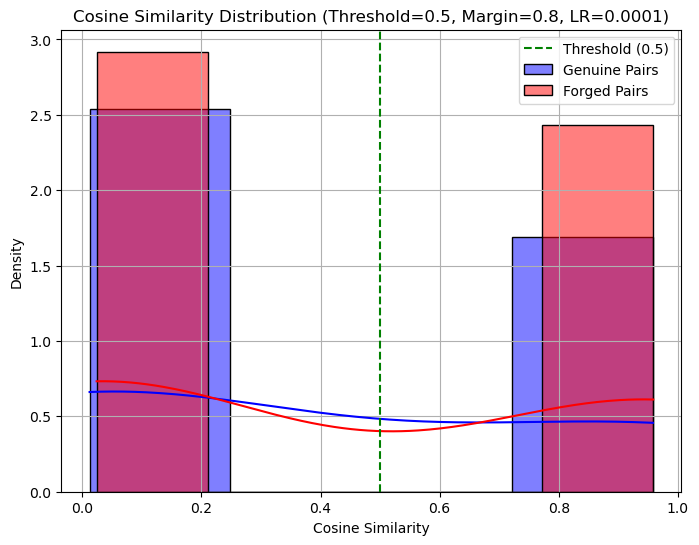

In [11]:
# model_path = f"second_saved_models/savedmodels/dropoutCNN/siamese_margin{margin}_size64_dropout4_lr{lr}.pt"
# model.load_state_dict(torch.load(model_path, map_location=device))
# # torch.cuda.empty_cache()  # Clears GPU cache in PyTorch
# model.eval()
# correct = 0
# total = 0
# cosine_sim_all = []
# labels_all = []
# emb1_array=[]
# with torch.no_grad():
#     for img1_array, img2, labels in val_loader:
#         for img1 in img1_array:
#             img1 = img1.to(device, non_blocking=True)
#             with autocast("cuda", dtype=torch.bfloat16):
#                 emb1 = model(img1)
#                 emb1_array.append(emb1)
#         emb1=torch.tensor(emb1)
#         emb1=torch.cat(emb1_array,dim=0).mean(dim=0)
        
#         img2 = img2.to(device, non_blocking=True)
#         labels = labels.to(device, non_blocking=True)
#         with autocast("cuda", dtype=torch.bfloat16):
#             emb2 = model(img2)
            
#         cosine_sim = F.cosine_similarity(emb1, emb2)
#         # cosine_sim=F.normalize(cosine_sim)
#         # cosine_sim=F.pairwise_distance(emb1, emb2)
#         cosine_sim= (1-cosine_sim)/2
#     cosine_sim_all.append(cosine_sim)
#     labels_all.append(labels)
#     # predictions = (cosine_sim < threshold).float()
#     # correct += (predictions == labels).sum().item()
#     total += labels.size(0)

    
#     cosine_sim_all = torch.cat(cosine_sim_all)
# labels_all = torch.cat(labels_all)
# y_true = labels_all.cpu().numpy()
# y_pred = (cosine_sim_all.cpu().numpy() < threshold).astype(int)

# print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
# print(f"Precision: {precision_score(y_true, y_pred):.4f}")
# print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
# print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
# print(f"AUC:       {roc_auc_score(y_true, 1 - cosine_sim_all.cpu().numpy()):.4f}")

# # Histogram
# indices = np.random.permutation(total)[:1000]
# cosine_sim_np = cosine_sim_all[indices].cpu().numpy()
# labels_np = labels_all[indices].cpu().numpy()
# cosine_sim_genuine = cosine_sim_np[labels_np == 1].tolist()
# cosine_sim_forged = cosine_sim_np[labels_np == 0].tolist()

# plt.figure(figsize=(8, 6))
# sns.histplot(cosine_sim_genuine, color='blue', label='Genuine Pairs', kde=True, stat='density')
# sns.histplot(cosine_sim_forged, color='red', label='Forged Pairs', kde=True, stat='density')
# plt.axvline(x=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
# plt.xlabel('Cosine Similarity')
# plt.ylabel('Density')
# plt.title(f'Cosine Similarity Distribution (Threshold={threshold}, Margin={margin}, LR={lr})')
# plt.legend()
# plt.grid(True)
# # plt.savefig(f"second_saved_models/saved_models/LENET/cosine_sim/cosine_similarity_distribution_threshold_{threshold}_{margin}_{lr}.png")
# plt.show()  # Display the plot
# plt.close()


In [ ]:
# # Load the model
# model = SiameseCNN().to(device)
# try:
#     model.load_state_dict(torch.load(PATH, map_location=device))
# except RuntimeError as e:
#     print(f"Error loading model: {e}")


In [ ]:
genuine_count = 0
forged_count = 0
total_samples = 0
for img1, img2, labels in dataloader:
    genuine_count += (labels == 1).sum().item()
    forged_count += (labels == 0).sum().item()
    total_samples += labels.size(0)
print(f"Genuine: {genuine_count} ({genuine_count / total_samples * 100:.2f}%), Forged: {forged_count} ({forged_count / total_samples * 100:.2f}%)")

In [ ]:
def evaluate_accuracy(model, testdataloader, margin, lr, threshold=0.5, device="cuda"):
    torch.cuda.empty_cache()  # Clears GPU cache in PyTorch
    model.eval()
    correct = 0
    total = 0
    cosine_sim_all = []
    labels_all = []
    
    with torch.no_grad():
        for img1, img2, labels in testdataloader:
            img1 = img1.to(device, non_blocking=True)
            img2 = img2.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            try:
                with autocast():
                    emb1 = model(img1)
                    emb2 = model(img2)
                    emb1 = F.normalize(emb1, p=2, dim=1)
                    emb2 = F.normalize(emb2, p=2, dim=1)
                    cosine_sim = F.cosine_similarity(emb1, emb2)
                cosine_sim_all.append(cosine_sim)
                labels_all.append(labels)
                predictions = (cosine_sim > threshold).float()
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
            except RuntimeError as e:
                print(f"Error in evaluation: {e}")
                if "out of memory" in str(e):
                    torch.cuda.empty_cache()
                    continue

    cosine_sim_all = torch.cat(cosine_sim_all)
    labels_all = torch.cat(labels_all)

    # Histogram
    indices = np.random.permutation(total)[:1000]
    cosine_sim_np = cosine_sim_all[indices].cpu().numpy()
    labels_np = labels_all[indices].cpu().numpy()
    cosine_sim_genuine = cosine_sim_np[labels_np == 1].tolist()
    cosine_sim_forged = cosine_sim_np[labels_np == 0].tolist()

    plt.figure(figsize=(8, 6))
    sns.histplot(cosine_sim_genuine, color='blue', label='Genuine Pairs', kde=True, stat='density')
    sns.histplot(cosine_sim_forged, color='red', label='Forged Pairs', kde=True, stat='density')
    plt.axvline(x=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Density')
    plt.title(f'Cosine Similarity Distribution (Threshold={threshold}, Margin={margin}, LR={lr})')
    plt.legend()
    plt.grid(True)
    plt.savefig(f"saved_models/LENET/cosine_similarity_distribution_threshold_{threshold}_{margin}_{lr}.png")
    plt.show()  # Display the plot
    plt.close()

    # Confusion Matrix
    predictions = (cosine_sim_all > threshold).float()
    cm = confusion_matrix(labels_all.cpu(), predictions.cpu())
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Forged', 'Genuine'], yticklabels=['Forged', 'Genuine'])
    plt.title(f'Confusion Matrix (Threshold={threshold}, Margin={margin}, LR={lr})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f"saved_models/LENET/confusion_matrix_threshold_{threshold}_{margin}_{lr}.png")
    plt.show()  # Display the plot
    plt.close()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels_all.cpu(), cosine_sim_all.cpu())
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (Threshold={threshold}, Margin={margin}, LR={lr})')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.savefig(f"saved_models/LENET/roc_curve_threshold_{threshold}_{margin}_{lr}.png")
    plt.show()  # Display the plot
    plt.close()

    # Metrics
    accuracy = correct / total if total > 0 else 0.0
    precision, recall, f1, _ = precision_recall_fscore_support(labels_all.cpu(), predictions.cpu(), average='binary')
    print(f"Threshold: {threshold}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}")
    
    return accuracy

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SiameseCNN().to(device)  # Initialize model outside the loop
thresholds = [0.93]

# Load and evaluate models
for filename in os.listdir('./saved_models/LENET/'):
    if filename.endswith('.pt'):
        PATH = os.path.join('./saved_models/LENET', filename)
        parts = filename.split('_')
        margin = parts[1]  # e.g., 'margin0.5'
        lr = parts[2].replace('.pt', '')  # e.g., 'lr0.001'
        print(f"Attempting to load model: {filename}")
        print(margin,lr)
        if(margin=='margin0.8size256' and lr=="lr0.005"):
            try:
                model.load_state_dict(torch.load(PATH, map_location=device))
                print(f"Successfully loaded model from {PATH}")
                for thresh in thresholds:
                    accuracy = evaluate_accuracy(model, testdataloader, margin, lr, threshold=thresh, device=device)
                    print(f"Model: {filename}, Threshold: {thresh}, Accuracy: {accuracy:.4f}")
            except Exception as e:
                print(f"Error loading model {filename}: {e}")